# Q12 — Are improvements worth the computational cost?

Hypothesis: BPMA is most attractive when families have unequal predictive value and individual fits are expensive. Compare quality-versus-budget curves and record fit count, ESS, and wall time.

In [1]:
from pathlib import Path
import sys
from time import perf_counter
root = Path.cwd()
while root != root.parent and not (root / 'bayesian_predictive_model_averaging').is_dir():
    root = root.parent
sys.path.insert(0, str(root))
from sklearn.metrics import log_loss
from EXPERIMENTS.common import classification_data, split_data, fit_classifier

In [2]:
X, y = classification_data(seed=43, kind='nonlinear')
X_train, X_test, y_train, y_test = split_data(X, y, seed=43)
budgets = [8, 16, 32, 64]
results = []
for budget in budgets:
    start = perf_counter()
    model = fit_classifier(X_train, y_train, seed=43, n_estimators=budget)
    results.append({
        'draws': budget,
        'log_loss': log_loss(y_test, model.predict_proba(X_test)),
        'ess_fraction': model.effective_sample_size_fraction_,
        'seconds': perf_counter() - start,
    })
results

[{'draws': 8,
  'log_loss': 0.4689777414891195,
  'ess_fraction': 0.9987595542512051,
  'seconds': 1.8383803750039078},
 {'draws': 16,
  'log_loss': 0.46927176787107727,
  'ess_fraction': 0.9988896056594684,
  'seconds': 4.358566083014011},
 {'draws': 32,
  'log_loss': 0.4679445301197862,
  'ess_fraction': 0.998502026576316,
  'seconds': 5.941408834012691},
 {'draws': 64,
  'log_loss': 0.45165851585307093,
  'ess_fraction': 0.9986676924441025,
  'seconds': 12.583471125049982}]

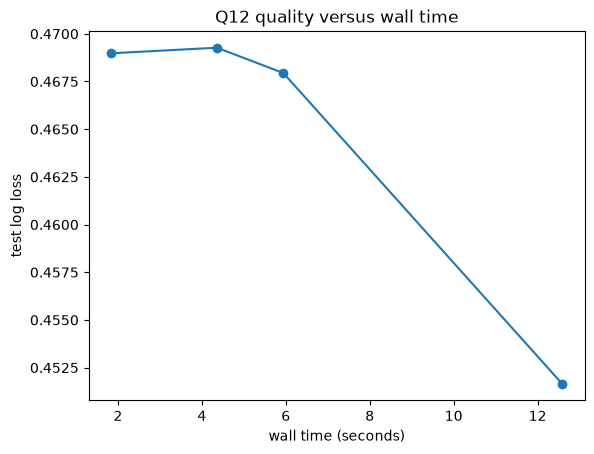

In [3]:
import matplotlib.pyplot as plt
plt.plot([row['seconds'] for row in results], [row['log_loss'] for row in results], marker='o')
plt.xlabel('wall time (seconds)')
plt.ylabel('test log loss')
plt.title('Q12 quality versus wall time')
plt.show()
# Repeat with adaptive runs and serial/parallel settings under fixed seeds.


The final analysis should include CPU model, number of workers, peak memory, CV-fit count, and quality per fit. Do not compare wall time across machines without recording hardware.

## Conclusion from the executed starter run

**Status: not falsified; a budget-quality trade-off is visible.** Test log loss was about 0.469 for 8–32 draws and improved to 0.4517 at 64 draws, while runtime increased from 1.84 seconds to 12.58 seconds. This supports measuring quality per budget, but it is one seed and does not yet compare adaptive allocation or parallel execution.